#### spateGAN-ERA5 spatiotemporal precipitation downscaling example
https://www.nature.com/articles/s41612-025-01103-y

In [1]:
%load_ext autoreload
%autoreload 2
import torch
import xarray as xr
import numpy as np
from einops import rearrange
import sys
import os
import pathlib
import matplotlib.pyplot as plt
from matplotlib import gridspec
sys.path.append(os.path.abspath("../"))

from src.spategan_era5.model import Generator  
from src.spategan_era5.inference import InferenceEngine

In [2]:
project_root = pathlib.Path(os.getcwd()).parent
model_path = project_root / 'model_weights' / 'model_weights.pt' # Path to the model weights
fn_test_y = project_root / 'data' / 'y_test.nc' # Path to the test dataset targets
fn_test_x = project_root / 'data' / 'x_test.nc' # Path to the test dataset input

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


#### load model and weights

In [4]:
spateGAN_era5 = Generator().to(device)

In [6]:
# Load the state_dict
checkpoint = torch.load(model_path, map_location=torch.device('cpu'), weights_only=True)
spateGAN_era5.load_state_dict(checkpoint, strict=True)
spateGAN_era5.eval()
print("Model weights loaded successfully.")

Model weights loaded successfully.


#### Load example dataset
Model expects ERA5 input data, projected to a regular 24x24 km grid. \
Target radar observations lay on a regular 2x2 km grid, 10 min. resolution

In [7]:
ds_test_y = xr.open_dataset(fn_test_y).load()
ds_test_x = xr.open_dataset(fn_test_x).load()

In [22]:
# aldsal
print(ds_test_x)

<xarray.Dataset> Size: 201kB
Dimensions:  (time: 32, y: 28, x: 28)
Coordinates:
  * time     (time) datetime64[ns] 256B 2021-08-04T20:00:00 ... 2021-08-06T03...
  * y        (y) float64 224B -4.419e+03 -4.395e+03 ... -3.795e+03 -3.771e+03
  * x        (x) float64 224B -229.0 -205.0 -181.0 -157.0 ... 371.0 395.0 419.0
Data variables:
    cp       (time, y, x) float32 100kB 0.0 0.0 0.0 0.0 ... 0.001173 0.0 0.0
    lsp      (time, y, x) float32 100kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    description:  ERA5 lsp and cp projected to RADOLAN grid, resolution: 24x2...
    author:       Data access: https://doi.org/10.1002/qj.3803,  API: https:/...
    created:      2025-04-08


In [23]:
x_test = np.stack([ds_test_x.cp.values, ds_test_x.lsp.values])
x_test = rearrange(x_test, 'c t h w -> 1 c t h w')
y_test = rearrange(ds_test_y.rainfall_amount.values, 't h w -> 1 1 t h w')

In [25]:
x_test.shape, y_test.shape

((1, 2, 32, 28, 28), (1, 1, 192, 168, 168))

#### Downscale data to 2x2km & 10 min resolution

Patchsizes:\
x: (batch, channels, time, width, height) = (batch, 2, 16, 28, 28) = (batch, CP & LSP, 16hr, 672km, 672km) \
y: (batch, channels, time, width, height) = (batch, 1, 48, 168, 168) = (batch,TP, 8hr, 336km, 336km) --> cropped to (batch,TP, 6hr, 288km, 288km)

In [26]:
# Initialize InferenceEngine
engine = InferenceEngine(spateGAN_era5)

In [27]:
# Perform inference
prediction, target, era5 = engine.infer(x_test, target=y_test, seed=4)

KeyboardInterrupt: 

#### Plot results

In [11]:
timestep = 100
vmax = 20
vmin = 0.01

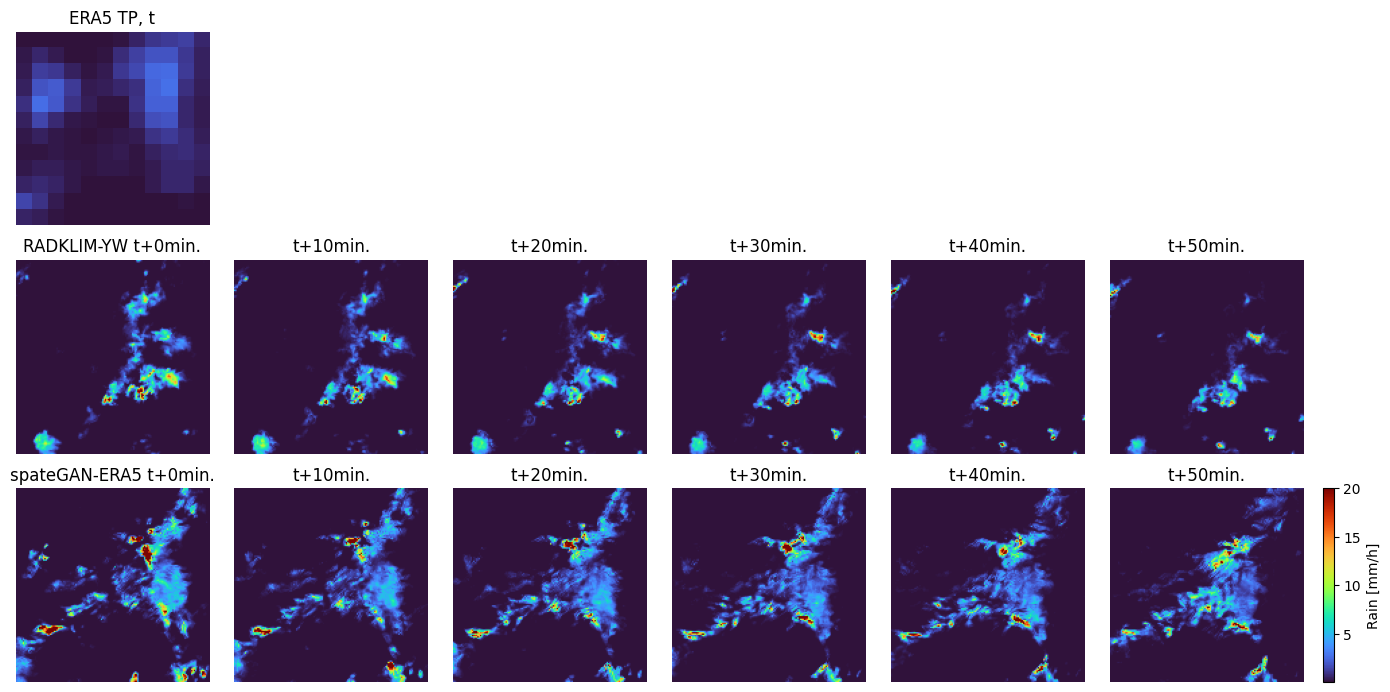

In [12]:
fig = plt.figure(figsize=(14, 7))
gs = gridspec.GridSpec(3, 7, figure=fig, width_ratios=[1]*6 + [0.05])

# Plot ERA5 TP data
ax = fig.add_subplot(gs[0,0])
img = ax.imshow(era5[timestep//6], cmap='turbo', vmin=vmin, vmax=vmax)
ax.set_title(f"ERA5 TP, t")
ax.axis('off') 

axes_tar = []
for j in range(6):
    ax = fig.add_subplot(gs[1, j])
    axes_tar.append(ax)

axes_pred = []
for j in range(6):
    ax = fig.add_subplot(gs[2, j])
    axes_pred.append(ax)


# Plot RADKLIM-YW data
for i, ax in enumerate(axes_tar):
    img = ax.imshow(target[timestep+i], cmap='turbo', vmin=vmin, vmax=vmax)
    if i == 0:
        ax.set_title(f"RADKLIM-YW t+{i*10}min.")
    else:
        ax.set_title(f"t+{i*10}min.")
    ax.axis('off') 

# Plot predictions
for i, ax in enumerate(axes_pred):
    img = ax.imshow(prediction[timestep+i], cmap='turbo', vmin=vmin, vmax=vmax)
    if i == 0:
        ax.set_title(f"spateGAN-ERA5 t+{i*10}min.")
    else:
        ax.set_title(f"t+{i*10}min.")
    ax.axis('off')  

# Add the colorbar
colorbar_ax = fig.add_subplot(gs[-1, 6]) 
fig.colorbar(img, cax=colorbar_ax, label='Rain [mm/h]')  

plt.tight_layout()
plt.show()
